<a href="https://colab.research.google.com/github/elkins/synth-suite/blob/main/docs/end_to_end_validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# End-to-End Validation (synth-suite)

This tutorial showcases the full ecosystem integration. We take a single protein structure and simulate observables across four orthogonal biophysical modalities: **NMR, SAXS, AFM, and Cryo-EM**. 

This multi-modal approach is exactly how modern computational structural biology validates predictions against experimental data.

In [1]:
import sys
if "google.colab" in sys.modules:
    !pip install -q synth-nmr synth-saxs synth-afm synth-cryo-em biotite matplotlib
else:
    import os
    for p in ["synth-nmr", "synth-saxs", "synth-afm", "synth-cryo-em"]:
        sys.path.append(os.path.abspath(f"../../{p}"))

import matplotlib.pyplot as plt
import numpy as np
import biotite.structure.io as strucio


## 1. The Target Structure
We'll download a common test protein, Ubiquitin (1UBQ).

In [2]:
import biotite.structure.io as strucio
import biotite.database.rcsb as rcsb

pdb_file = rcsb.fetch("1UBQ", "pdb", ".")
structure = strucio.load_structure(pdb_file)
protein = structure[structure.hetero == False]

coords = protein.coord
elements = protein.element
print(f"Loaded {len(coords)} atoms.")

Loaded 602 atoms.


## 2. NMR: Predict Chemical Shifts
Using `synth-nmr`, we predict the $C\alpha$ chemical shifts directly from the 3D topology.

In [3]:
from synth_nmr import predict_chemical_shifts

shifts = predict_chemical_shifts(protein)
print(f"Predicted CA shift for Residue 1: {shifts.get('A', {}).get(1, {}).get('CA', 'N/A')} ppm")

SHIFTX2 executable not found. Falling back to empirical SPARTA+ model. To use SHIFTX2, ensure it is in your PATH or set the SHIFTX2_DIR environment variable. For installation, see http://www.shiftx2.ca/download.html or use SBGrid ('sbgrid-cli install shiftx2').


Predicted CA shift for Residue 1: 55.396 ppm


## 3. SAXS: Predict Scattering Profile
Using `synth-saxs`, we generate the $I(q)$ curve.

In [4]:
from synth_saxs import calculate_saxs_profile

q_values, intensities = calculate_saxs_profile(protein, q_min=0.01, q_max=0.3, n_points=50)
print(f"Generated SAXS profile across {len(q_values)} q-bins.")

Generated SAXS profile across 50 q-bins.


## 4. AFM: Simulate Topography
Using `synth-afm`, we sweep a simulated 1.0 Å tip over the grid to capture the height map.

In [5]:
from synth_afm import AFMSimulator

afm_sim = AFMSimulator(grid_size=(50, 50), pixel_size=0.8, tip_radius=1.0)
height_map = afm_sim.scan(coords)
print("AFM scan complete.")

AFM scan complete.


## 5. Cryo-EM: Synthesize Density Map
Using `synth-cryo-em`, we drop Gaussian blobs at each atomic coordinate to build a 3D volume.

In [6]:
from synth_cryo_em.core import generate_density_map
import numpy as np

# 1.0 Å spacing, 3.0 Å resolution
density_grid, min_pos = generate_density_map(pdb_file, resolution=3.0, grid_spacing=1.0)
density_map = np.array(density_grid, copy=False)
print("Cryo-EM density synthesis complete.")

Cryo-EM density synthesis complete.


## 6. Multi-Modal Dashboard
Let's visualize the results of all four simulations.

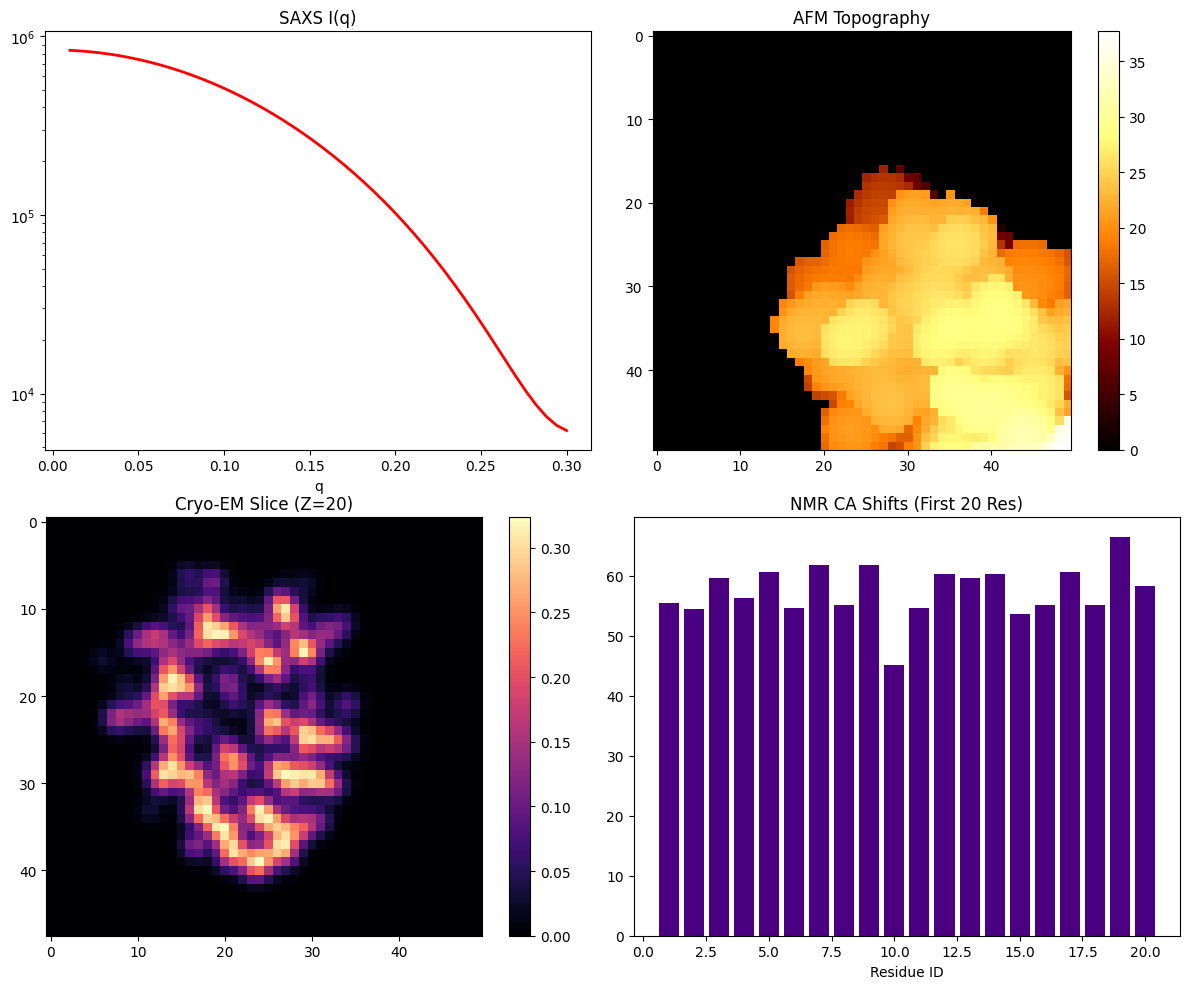

In [7]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Top-Left: SAXS
axes[0, 0].plot(q_values, intensities, 'r-', linewidth=2)
axes[0, 0].set_yscale('log')
axes[0, 0].set_title("SAXS I(q)")
axes[0, 0].set_xlabel("q")

# Top-Right: AFM
im_afm = axes[0, 1].imshow(height_map, cmap='afmhot')
axes[0, 1].set_title("AFM Topography")
fig.colorbar(im_afm, ax=axes[0, 1])

# Bottom-Left: Cryo-EM Slice
mid_z = density_map.shape[0] // 2
im_em = axes[1, 0].imshow(density_map[mid_z, :, :], cmap='magma')
axes[1, 0].set_title("Cryo-EM Slice (Z=20)")
fig.colorbar(im_em, ax=axes[1, 0])

# Bottom-Right: NMR Chemical Shifts
res_ids = sorted(shifts['A'].keys())
ca_values = [shifts['A'][i].get('CA', 0) for i in res_ids]
axes[1, 1].bar(res_ids[:20], ca_values[:20], color='indigo')
axes[1, 1].set_title("NMR CA Shifts (First 20 Res)")
axes[1, 1].set_xlabel("Residue ID")

plt.tight_layout()
plt.show()